# 04. Vision Models

## GAN Problems

- Incredibly hard to train.
    - You have to really pay attension to the learning_rate
    - Use the best optimizers
        - AdamW for Images
    - Curate your dataset carefully
    - Still the loss function explodes to infinity and you have to go back a couple of steps and retry
        - Add noise
        - Reinitialize some of the weights
        - Train again
- Very unstable in general during training, but give good results
- Mode collapse
    - If the generator finds 1 good image, it starts to generate only that image
 
## GAN vs Diffusion control

- Diffusion is more easily controlled with text prompts
- GANs are more easily controlled with numbers
    - The Wasserstein Generative Adversarial Network (WGAN) is a variant of generative adversarial network (GAN) proposed in 2017 that aims to "improve the stability of learning, get rid of problems like mode collapse, and provide meaningful learning curves useful for debugging and hyperparameter searches".
    - Compared with the original GAN discriminator, the Wasserstein GAN discriminator provides a better learning signal to the generator. This allows the training to be more stable when generator is learning distributions in very high dimensional spaces.
    - This allows us to control and also UNDERSTAND what the GAN does. At certain numbers we know what happens.

## Reasons not to use DNN for CV

1. Specific hardware constraints (LLMS are big and heavy) edge devices for example
2. We want interpretability
3. There is no similar task (usually if there is, transfter learning is very easy in CV)

In [65]:
import os
# 0 = all messages (default)
# 1 = filter out INFO
# 2 = filter out INFO and WARNING (This is usually the sweet spot)
# 3 = filter out INFO, WARNING, and ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import keras
import matplotlib.pyplot as plt

from keras.datasets import cifar10

from keras.models import Sequential
from keras.layers import Input, Flatten, Conv2D, Dense, Dropout, SpatialDropout2D, BatchNormalization, MaxPooling2D
from keras import regularizers

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Here we can load the whole dataset in memory, but this almost never happens. This example is small for easy of use and simplicity, but usually we have to work with chunks of the dataset one at a time.

In [4]:
(x_train.shape, y_train.shape), (x_test.shape, y_test.shape)

(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

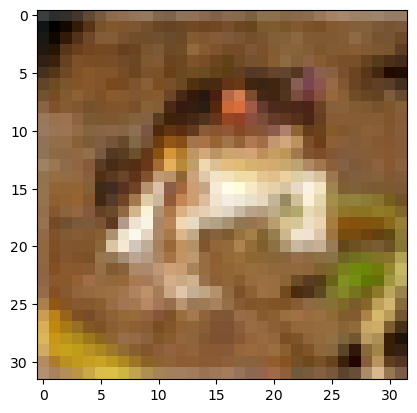

In [7]:
plt.imshow(x_train[0])

In [9]:
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 3) # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
])

I0000 00:00:1770401831.098817    2682 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:08:00.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,584 (14.00 KB)

 Trainable params: 3,584 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Conv2D saves a lot of params.

Usually if we have an image (2000 x 2000 x 3) x (256 Dense layer) this explodes to be billions. A whole LLM is that many params. Insane. This is just from a flatten of an ordinary image.

But we don't want Dense layers, since not all pixels make sense to be looked at together. So we pick a small sliding window (convolution) and use that instead. In our case we have 128 filters that are 3x3, much better.

Now the params are (2000 * 2000 * 128)  not 3 billion.

The filters are initialized with RANDOM numbers, not 1s or 0s.


In [17]:
model.layers[0].weights[0] # weights

<Variable path=sequential/conv2d/kernel, shape=(3, 3, 3, 128), dtype=float32, value=[[[[-0.044707    0.04708423  0.0105571  ... -0.04977095  0.001133
    -0.03004128]
   [-0.00498591  0.06881107 -0.07103527 ... -0.06110434 -0.05092895
     0.06522624]
   [-0.07062523  0.00538557 -0.04420482 ... -0.00137028 -0.02430748
    -0.06280994]]

  [[-0.0440601  -0.002037    0.02485721 ...  0.01157731  0.0189785
     0.05246451]
   [-0.01756978 -0.00647321  0.02548226 ...  0.00225684  0.00248189
    -0.0585354 ]
   [ 0.00435665 -0.00599713  0.00771751 ...  0.0280189  -0.03477133
    -0.03555765]]

  [[-0.0420336  -0.02257169 -0.03627925 ... -0.04142127 -0.03638044
     0.01678985]
   [-0.04184063 -0.06407775  0.06921086 ...  0.04875948 -0.04097222
    -0.0100317 ]
   [-0.05037494  0.01008383  0.00584088 ... -0.03358297 -0.02285197
    -0.02552896]]]


 [[[ 0.0320949   0.07082613  0.03564361 ...  0.0523994   0.03029769
    -0.01434621]
   [-0.05872535  0.00359093 -0.05422232 ... -0.04988237 -0.06

In [18]:
model.layers[0].weights[0].shape

TensorShape([3, 3, 3, 128])

In [16]:
model.layers[0].weights[1] #bias

<Variable path=sequential/conv2d/bias, shape=(128,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]>

The bias is 0 as we can see.

In [20]:
model.layers[0].weights[1].shape

TensorShape([128])

The kernal usually needs to be an odd number so it has a central pixel. This makes the size smaller and smaller with each Conv2D layer, so we can add padding:
- Valid padding - no padding is applied
- Same padding - Adds as many pixels as we would lose in the convolution

## Model training

In [42]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

In [43]:
keras.backend.clear_session()
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 11, padding = 'same', activation = "relu"), # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
    Conv2D(filters = 64, kernel_size = 7, padding = 'same', activation = "relu"),
    Conv2D(filters = 32, kernel_size = 5, padding = 'same', activation = "relu"),
    Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = "relu"),

    Flatten(),
    Dense(units = 10, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │        46,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       163,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,770 (2.55 MB)

 Trainable params: 667,770 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

We can use "relu" for an activation function, but some of the neurons can be left "dead". I wouldn't use RELU in general, better options exist.

Images are harder to understand than text. They have more information density.

In [44]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics = ["accuracy"])

In [45]:
model.fit(x_train, y_train, epochs = 3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.3604 - loss: 1.7500
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.4954 - loss: 1.4070
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5525 - loss: 1.2567


In [46]:
model.fit(x_train, y_train, epochs = 7)

Epoch 1/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5956 - loss: 1.1444
Epoch 2/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6318 - loss: 1.0419
Epoch 3/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6667 - loss: 0.9436
Epoch 4/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7039 - loss: 0.8436
Epoch 5/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7354 - loss: 0.7538
Epoch 6/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7625 - loss: 0.6698
Epoch 7/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7900 - loss: 0.5939


In [47]:
model.fit(x_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8128 - loss: 0.5300
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8351 - loss: 0.4659
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8540 - loss: 0.4118
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8701 - loss: 0.3642
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8812 - loss: 0.3328
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8906 - loss: 0.3051
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9002 - loss: 0.2804
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9066 - loss: 0.2658
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9107 - loss: 0.2506
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.9178 - loss: 0.2296


With LLM transformers, we usually 1 or 2 MAX epochs. If it sees the data again it will overfit.

With Images, that is not the case. Usually you can see, 1000, 3000, 10000 epochs of seeing the same data again and again and we use more conservative learning_rates.

In [48]:
model.evaluate(x_test, y_test)

2026-02-06 21:15:58.833941: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,32,32]{3,2,1,0}, f32[32,64,5,5]{3,2,1,0}, f32[32]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:15:59.089702: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,32,32]{3,2,1,0}, f32[16,32,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5046 - loss: 3.5531

2026-02-06 21:16:02.262187: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,32,32]{3,2,1,0}, f32[32,64,5,5]{3,2,1,0}, f32[32]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:16:02.419799: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,32,32]{3,2,1,0}, f32[16,32,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5060 - loss: 3.6015


[3.6015305519104004, 0.5059999823570251]

We see a lot of overfitting. So lets regularaize

We can use a parametern on Conv2D() layer or we can use Dropout(). 

For Convolutions it is actually really good to use the layer param. Do not use Dropout, because instead of removing some filters/kernals it removes part of them. We don't want that.

We could use SpatialDropout2D() which does that filter removal.

In [66]:
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = "relu", kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)), # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = "relu"),
    SpatialDropout2D(0.1),
    Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = "relu", kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = "relu"),
    SpatialDropout2D(0.1),
    
    Flatten(),
    Dropout(0.4),
    Dense(units = 10, activation = "softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics = ["accuracy"])
model.fit(x_train, y_train, epochs = 10, validation_split=0.05)

model.summary()

Epoch 1/10


2026-02-06 21:36:50.633020: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:36:50.653547: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,16,16]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="

1483/1485 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3513 - loss: 1.8199 

2026-02-06 21:37:03.196959: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:37:03.209006: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,128,16,16]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3514 - loss: 1.8196

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 8, 8, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,424 (1.27 MB)

 Trainable params: 111,034 (433.73 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 222,070 (867.46 KB)

In [68]:
model.fit(x_train, y_train, epochs = 10, validation_split=0.05)

Epoch 1/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7150 - loss: 0.8518 - val_accuracy: 0.7184 - val_loss: 0.8443
Epoch 2/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7177 - loss: 0.8370 - val_accuracy: 0.7576 - val_loss: 0.7656
Epoch 3/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7229 - loss: 0.8247 - val_accuracy: 0.7532 - val_loss: 0.7644
Epoch 4/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7282 - loss: 0.8087 - val_accuracy: 0.6748 - val_loss: 1.0089
Epoch 5/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7319 - loss: 0.7995 - val_accuracy: 0.7312 - val_loss: 0.8320
Epoch 6/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7376 - loss: 0.7883 - val_accuracy: 0.7564 - val_loss: 0.7716
Epoch 7/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7403 - loss: 0.7783 - val_accuracy: 0.7360 - val_loss: 0.8260
Epoch 8/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7434 - loss: 0.7683 - 

In [69]:
model.fit(x_train, y_train, epochs = 20, validation_split=0.05)

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7510 - loss: 0.7498 - val_accuracy: 0.7696 - val_loss: 0.7270
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7544 - loss: 0.7406 - val_accuracy: 0.7732 - val_loss: 0.7369
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7606 - loss: 0.7289 - val_accuracy: 0.7536 - val_loss: 0.7600
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7620 - loss: 0.7238 - val_accuracy: 0.7520 - val_loss: 0.7701
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7632 - loss: 0.7179 - val_accuracy: 0.7588 - val_loss: 0.7889
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7685 - loss: 0.7095 - val_accuracy: 0.7636 - val_loss: 0.7263
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7677 - loss: 0.7032 - val_accuracy: 0.7800 - val_loss: 0.6970
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7698 - loss: 0.7021 - 

We can see MaxPooling does downsampling which greatly reduces computational times and overfitting. Seems to have fixed the problem we had. But we can't push past 70% now.

We can add early stopping, or a scheduler to reduce learning_rate when it detects this behaviour. Also make the conv2D 2 consecutive. On and on. Play around.